# Pipe Diameter Optimization

This notebook solves the pipe-diameter optimization problem described in the project README. It finds the diameter that minimizes annual cost using a one-variable optimization model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from curved_text import CurvedText

In [2]:
class pipe:
    def __init__(self, mass_flow=50.0, density=60.0, viscosity=6.72e-4, pump_efficiency=0.6,
                 cost_coeff_pump=0.5938, cost_coeff_pipe=5.7, pipe_exponent=1.3,
                 pipe_length=1.0, gravitational_constant=32.174):
        self.mass_flow = mass_flow
        self.density = density
        self.viscosity = viscosity
        self.pump_efficiency = pump_efficiency
        self.cost_coeff_pump = cost_coeff_pump
        self.cost_coeff_pipe = cost_coeff_pipe
        self.pipe_exponent = pipe_exponent
        self.pipe_length = pipe_length
        self.gravitational_constant = gravitational_constant

    def total_cost(self, diameter):
        area = np.pi * diameter**2 / 4
        velocity = self.mass_flow / (self.density * area)
        reynolds = self.density * velocity * diameter / self.viscosity
        friction_factor = 0.046 * reynolds**-0.2
        friction_loss = 2 * friction_factor * self.pipe_length * velocity**2 / diameter

        capital = self.cost_coeff_pipe * diameter**self.pipe_exponent
        operating = (self.cost_coeff_pump / self.pump_efficiency) * \
            self.mass_flow * friction_loss / self.gravitational_constant
        return capital + operating

    def make_plot(self, optimal_diameter):
        diameters = np.linspace(0.2, 1.2, 300)
        capital = self.cost_coeff_pipe * diameters**self.pipe_exponent
        operating = np.array([self.total_cost(diameter)
                             for diameter in diameters]) - capital
        total = capital + operating

        fig, ax = plt.subplots(figsize=(8, 5.5))
        ax.plot(diameters, capital, lw=2, color="#1f77b4")
        ax.plot(diameters, operating, lw=2, color="#ff0e12")
        ax.plot(diameters, total, lw=2.5, color="#2ca02c")
        ax.axvline(optimal_diameter, color="grey", ls=":")
        ax.set_xlim(0.2, 1.2)
        ax.set_ylim(-2, 10)

        CurvedText(diameters, capital, "capital", ax, pos=0.070, offset=-7.5,
                   color="#1f77b4", fontsize=13, fontweight="bold")
        CurvedText(diameters, operating, "operating", ax, pos=0.1, offset=7.5,
                   color="#ff0e12", fontsize=13, fontweight="bold")
        CurvedText(diameters, total, "total", ax, pos=0.9, offset=8,
                   color="#2ca02c", fontsize=13, fontweight="bold")

        ax.plot(optimal_diameter, self.total_cost(optimal_diameter), "o", color="black", zorder=5)
        ax.annotate(f"D = {optimal_diameter:.3f} ft", xy=(optimal_diameter, self.total_cost(optimal_diameter)),
                    xytext=(8, 10), textcoords="offset points", fontsize=12, fontweight="bold")

        ax.set_xlabel("Diameter D (ft)")
        ax.set_ylabel("Annual cost ($/yr)")
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig("pipe_plot.png", dpi=300)
        plt.show()

In [3]:
def optimize_pipe(settings=None):
    if settings is None:
        settings = {
            "mass_flow": 50.0,
            "density": 60.0,
            "viscosity": 6.72e-4,
            "pump_efficiency": 0.6,
            "cost_coeff_pump": 0.5938,
            "cost_coeff_pipe": 5.7,
            "pipe_exponent": 1.3,
            "pipe_length": 1.0,
            "gravitational_constant": 32.174,
        }

    pipe_instance = pipe(**settings)
    result = minimize_scalar(pipe_instance.total_cost, bounds=(0.1, 2.0), method="bounded")

    if not result.success:
        raise RuntimeError(result.message)

    optimal_diameter = result.x
    optimal_velocity = pipe_instance.mass_flow / (pipe_instance.density * np.pi * optimal_diameter**2 / 4)

    print(f"Optimal diameter: {optimal_diameter:.4f} ft = {optimal_diameter * 12:.2f} in")
    print(f"Velocity:         {optimal_velocity:.2f} ft/s")
    return pipe_instance, optimal_diameter

Optimal diameter: 0.4733 ft = 5.68 in
Velocity:         4.74 ft/s


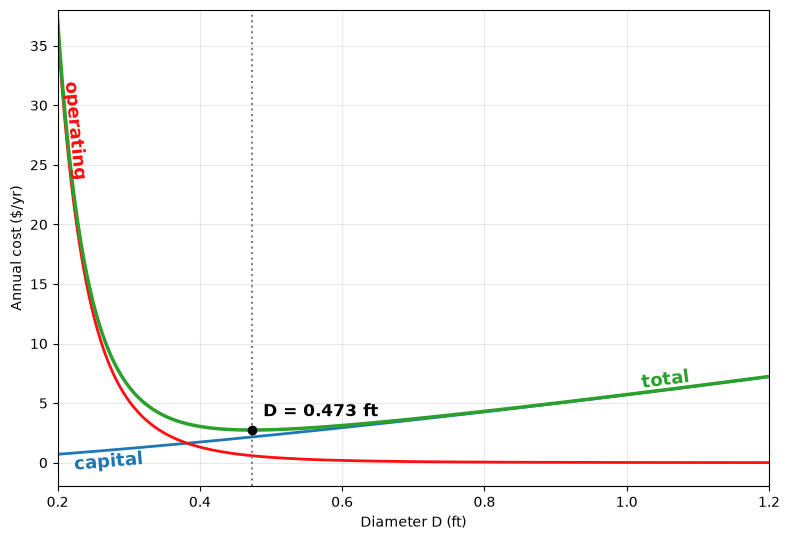

In [4]:
settings = {
    "mass_flow": 50.0,
    "density": 60.0,
    "viscosity": 6.72e-4,
    "pump_efficiency": 0.6,
    "cost_coeff_pump": 0.5938,
    "cost_coeff_pipe": 5.7,
    "pipe_exponent": 1.3,
    "pipe_length": 1.0,
    "gravitational_constant": 32.174,
}

pipe_instance, optimal_diameter = optimize_pipe(settings)
pipe_instance.make_plot(optimal_diameter)